Total blue cells detected: 193
Cells with radius > 50: 28


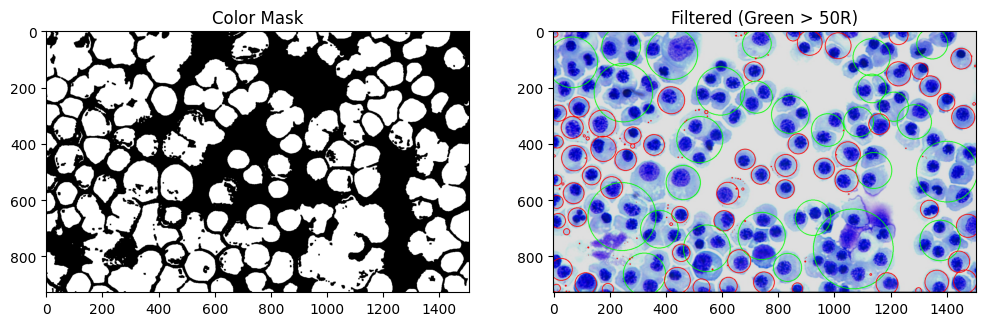

In [4]:

import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# First load the image
img = cv2.imread("image_pro1.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to HSV and mask colors
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Adjusting the bounds if some cells are missed
lower_blue = np.array([
    100,
    50,
    50
])
upper_blue = np.array([
    160,
    255,
    255
])
mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Morphological Cleaning
kernel = np.ones((5,
5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Connected Components Analysis
n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

total_blue_cells = 0
large_cells_count = 0
output_img = img_rgb.copy()

for i in range(1, n_labels):
    area = stats[i, cv2.CC_STAT_AREA
]

    # Calculating equivalent radius
    radius = math.sqrt(area / math.pi)
    total_blue_cells += 1

    # Filter by radius > 50
    if radius > 50:
        large_cells_count += 1
        # Draw green circle for large cells, red for small
        color = (0,
255,
0)
    else:
        color = (255,
0,
0)

    center = (int(centroids[i
][
    0
]), int(centroids[i
][
    1
]))
    cv2.circle(output_img, center, int(radius), color,
2)

#  Displaying Results
print(f"Total blue cells detected: {total_blue_cells}")
print(f"Cells with radius > 50: {large_cells_count}")

plt.figure(figsize=(12,
6))
plt.subplot(1,
2,
1)
plt.title("Color Mask")
plt.imshow(mask, cmap="gray")
plt.subplot(1,
2,
2)
plt.title("Filtered (Green > 50R)")
plt.imshow(output_img)
plt.show()
